In [1]:
!pip install -q matplotlib seaborn pandas numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Imports OK!')

Imports OK!


In [4]:
import json

# Carrega ocupações
occ = pd.read_csv('occupations.csv')

# Carrega pontuações de exposição à IA
with open('scores.json') as f:
    scores_raw = json.load(f)
scores = pd.DataFrame(scores_raw)[['slug', 'exposure']]

# Merge
df = occ.merge(scores, on='slug', how='inner')

print(f'Total de ocupações: {len(df)}')
df[['title', 'category', 'num_jobs_2024', 'outlook_pct', 'exposure']].head()

Total de ocupações: 342


,title,category,num_jobs_2024,outlook_pct,exposure
0,Accountants and auditors,business-and-financial,1579800.0,5.0,8
1,Actors,entertainment-and-sports,57000.0,0.0,7
2,Actuaries,math,33600.0,22.0,8
3,Administrative services and facilities managers,management,422600.0,4.0,5
4,Adult basic and secondary education and ESL te...,education-training-and-library,40900.0,-14.0,7


In [5]:
# Rótulos amigáveis para as categorias
category_labels = {
    'healthcare': 'Saúde',
    'architecture-and-engineering': 'Arquitetura e Engenharia',
    'life-physical-and-social-science': 'Ciências',
    'management': 'Gestão',
    'business-and-financial': 'Negócios e Finanças',
    'construction-and-extraction': 'Construção e Extração',
    'production': 'Produção',
    'installation-maintenance-and-repair': 'Instalação e Manutenção',
    'education-training-and-library': 'Educação',
    'office-and-administrative-support': 'Administrativo',
    'transportation-and-material-moving': 'Transporte e Logística',
    'personal-care-and-service': 'Cuidados Pessoais',
    'sales': 'Vendas',
    'media-and-communication': 'Mídia e Comunicação',
    'computer-and-information-technology': 'TI e Computação',
    'arts-and-design': 'Artes e Design',
    'community-and-social-service': 'Serviço Social',
    'entertainment-and-sports': 'Entretenimento e Esporte',
    'food-preparation-and-serving': 'Alimentação',
    'protective-service': 'Segurança Pública',
    'legal': 'Jurídico',
    'math': 'Matemática',
    'farming-fishing-and-forestry': 'Agropecuária',
    'building-and-grounds-cleaning': 'Limpeza e Manutenção',
    'military': 'Militar',
}

df['category_label'] = df['category'].map(category_labels).fillna(df['category'])

# Agrupa por categoria: média de exposição à IA, soma de empregos e média de crescimento
cat_df = df.groupby('category_label').agg(
    avg_exposure=('exposure', 'mean'),
    total_jobs=('num_jobs_2024', 'sum'),
    avg_outlook=('outlook_pct', 'mean'),
    n=('title', 'count')
).reset_index()

# Filtra categorias com pelo menos 4 ocupações para ter representatividade
cat_df = cat_df[cat_df['n'] >= 4].copy()

print(f'Categorias com >= 4 ocupações: {len(cat_df)}')
cat_df.sort_values('avg_exposure', ascending=False)

Categorias com >= 4 ocupações: 23


,category_label,avg_exposure,total_jobs,avg_outlook,n
14,Matemática,8.750000,426200.0,21.250000,4
22,TI e Computação,8.500000,4513700.0,8.300000,10
12,Jurídico,8.000000,1312600.0,1.800000,5
16,Mídia e Comunicação,7.800000,1164800.0,1.300000,10
0,Administrativo,7.692308,16488600.0,-5.307692,13
17,Negócios e Finanças,7.541667,9819000.0,4.750000,24
4,Artes e Design,7.111111,728500.0,1.333333,9
24,Vendas,7.000000,10828000.0,0.100000,10
3,Arquitetura e Engenharia,6.275862,2406700.0,4.034483,29
5,Ciências,6.206897,1143800.0,3.241379,29


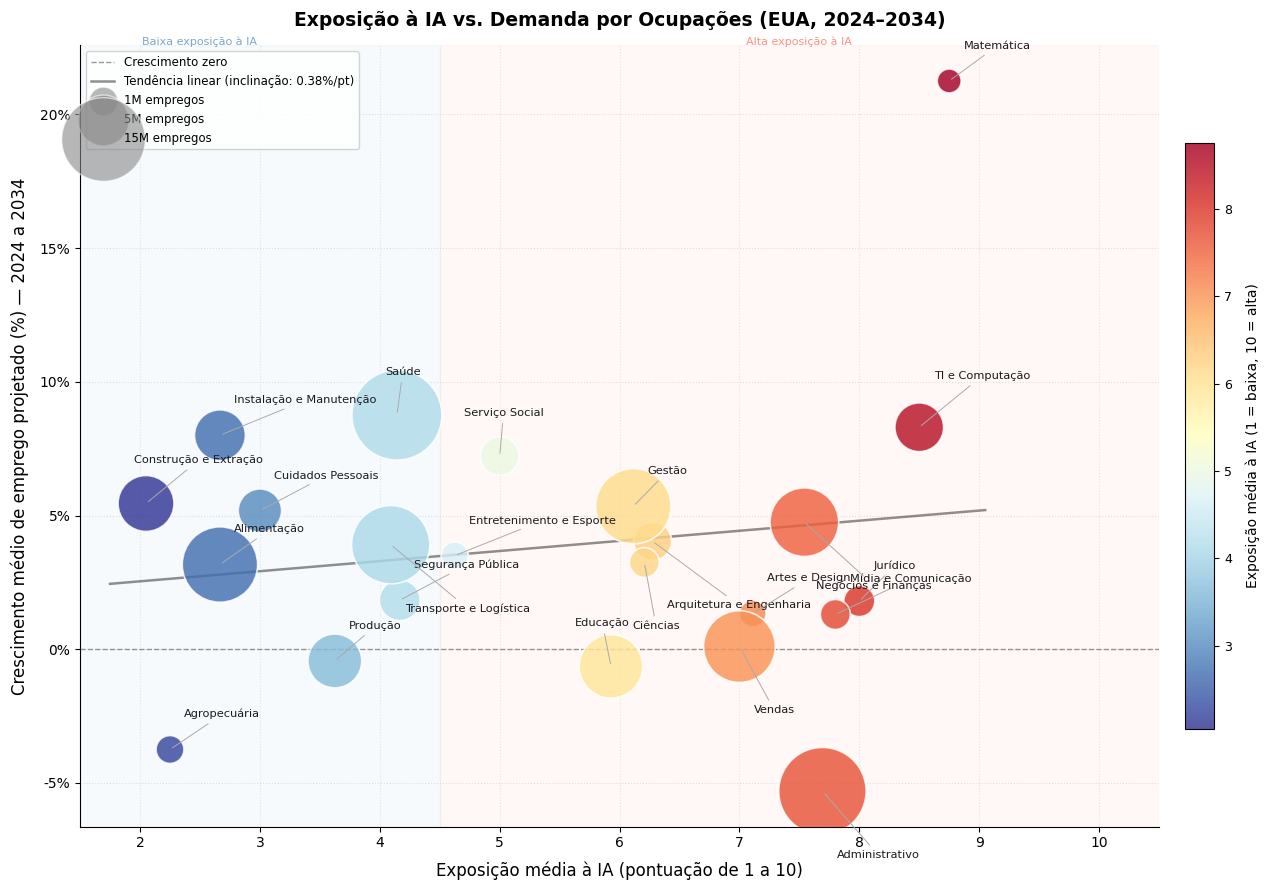

Figura salva como visualizacao_ia_ocupacoes.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 9))

# Paleta de cores baseada na exposição à IA
cmap = plt.cm.RdYlBu_r
norm = plt.Normalize(vmin=cat_df['avg_exposure'].min(), vmax=cat_df['avg_exposure'].max())

# Escala do tamanho das bolhas
size_scale = cat_df['total_jobs'] / cat_df['total_jobs'].max()
bubble_sizes = size_scale * 4000 + 200

scatter = ax.scatter(
    cat_df['avg_exposure'],
    cat_df['avg_outlook'],
    s=bubble_sizes,
    c=cat_df['avg_exposure'],
    cmap=cmap,
    norm=norm,
    alpha=0.82,
    edgecolors='white',
    linewidths=1.2,
    zorder=3
)

# Linha horizontal de crescimento zero (referência)
ax.axhline(0, color='#555555', linewidth=1.0, linestyle='--', alpha=0.6, zorder=2, label='Crescimento zero')

# Linha de tendência (regressão linear)
z = np.polyfit(cat_df['avg_exposure'], cat_df['avg_outlook'], 1)
p = np.poly1d(z)
x_line = np.linspace(cat_df['avg_exposure'].min() - 0.3, cat_df['avg_exposure'].max() + 0.3, 200)
ax.plot(x_line, p(x_line), color='#222222', linewidth=1.8, linestyle='-', alpha=0.5, zorder=2, label=f'Tendência linear (inclinação: {z[0]:.2f}%/pt)')

# Rótulos das categorias
offsets = {
    'TI e Computação':      ( 0.12,  1.8),
    'Saúde':                (-0.1,   1.5),
    'Negócios e Finanças':  ( 0.1,  -2.5),
    'Educação':             (-0.3,   1.5),
    'Jurídico':             ( 0.12,  1.2),
    'Administrativo':       ( 0.12, -2.5),
    'Produção':             ( 0.12,  1.2),
    'Transporte e Logística': ( 0.12, -2.5),
    'Construção e Extração': (-0.1,  1.5),
    'Gestão':               ( 0.12,  1.2),
    'Ciências':             (-0.1, -2.5),
    'Cuidados Pessoais':    ( 0.12,  1.2),
    'Arquitetura e Engenharia': (0.12, -2.5),
    'Agropecuária':         ( 0.12,  1.2),
    'Vendas':               ( 0.12, -2.5),
    'Serviço Social':       (-0.3,   1.5),
    'Segurança Pública':    ( 0.12,  1.2),
    'Mídias e Comunicação': ( 0.12, -2.5),
}

for _, row in cat_df.iterrows():
    dx, dy = offsets.get(row['category_label'], (0.12, 1.2))
    ax.annotate(
        row['category_label'],
        xy=(row['avg_exposure'], row['avg_outlook']),
        xytext=(row['avg_exposure'] + dx, row['avg_outlook'] + dy),
        fontsize=8.2,
        color='#1a1a1a',
        ha='left',
        arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.7),
        zorder=5
    )

# Colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.75)
cbar.set_label('Exposição média à IA (1 = baixa, 10 = alta)', fontsize=10, labelpad=10)
cbar.ax.tick_params(labelsize=9)

# Legenda de tamanho de bolha
for jobs_m, label in [(1, '1M'), (5, '5M'), (15, '15M')]:
    frac = jobs_m * 1_000_000 / cat_df['total_jobs'].max()
    sz = frac * 4000 + 200
    ax.scatter([], [], s=sz, c='#888888', alpha=0.6, label=f'{label} empregos', edgecolors='white')

# Zonas de fundo suave
ax.axvspan(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else 1, 4.5,
           alpha=0.04, color='steelblue', zorder=0)
ax.axvspan(4.5, 10.5,
           alpha=0.04, color='tomato', zorder=0)
ax.text(2.5, ax.get_ylim()[1] if ax.get_ylim() != (0,1) else 20,
        'Baixa exposição à IA', fontsize=8, color='steelblue', alpha=0.7, ha='center')
ax.text(7.5, ax.get_ylim()[1] if ax.get_ylim() != (0,1) else 20,
        'Alta exposição à IA', fontsize=8, color='tomato', alpha=0.7, ha='center')

# Formatação
ax.set_xlabel('Exposição média à IA (pontuação de 1 a 10)', fontsize=12, labelpad=8)
ax.set_ylabel('Crescimento médio de emprego projetado (%) — 2024 a 2034', fontsize=12, labelpad=8)
ax.set_title(
    'Exposição à IA vs. Demanda por Ocupações (EUA, 2024–2034)',
    fontsize=13.5, fontweight='bold', pad=14
)
ax.set_xlim(1.5, 10.5)
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.85, edgecolor='#cccccc')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('visualizacao_ia_ocupacoes.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figura salva como visualizacao_ia_ocupacoes.png')